In [170]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [171]:
data = pd.read_csv("train.csv")

In [172]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [173]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)


In [174]:
data_dev = data[0:1000].T
y_dev = data_dev[0]
x_dev = data_dev[1:n]

data_train = data[1000:m].T
y_train = data_train[0]
x_train = data_train[1:n]




In [175]:
x_train[:,0].shape # first collumn with 784 pixels in it 

(784,)

In [176]:
def init_params():
    #Changed: 
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

In [177]:
#activation functions
def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    #changed:
     #return np.exp(Z) / np.sum(np.exp(Z))
    exp_Z = np.exp(Z-np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis= 0, keepdims=True)
   

In [178]:
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

In [179]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    #we add 1 to Y.max() to get 10 (nr of output classes)
    one_hot_Y[np.arange(Y.size), Y] = 1 #0 to m, Y is our labels (column)
    #"for each row, go to the column specified by the label (Y) and set it to 1" - how the youtube explained
    one_hot_Y = one_hot_Y.T #each row is an example, we want each column to be an example
    return one_hot_Y

def deriv_ReLU(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    #one-hot encode Y
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m*dZ2.dot(A1.T)

    #changed:
    #db2 = 1 / m * np.sum(dZ2)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    #changed:
    #db1 = 1 / m * np.sum(dZ1)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    #alpha is learning rate
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [180]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(f"Predictions: {predictions}, labels: {Y}")
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params() #initial values

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if (i % 50 == 0):
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))

    return W1, b1, W2, b2





In [181]:
W1, b1, W2, b2 = gradient_descent(x_train, y_train, 500, 0.1)

Iteration:  0
Predictions: [1 9 1 ... 1 9 7], labels: [5 6 7 ... 2 7 5]
Accuracy:  0.14529268292682926
Iteration:  50
Predictions: [1 1 1 ... 1 1 1], labels: [5 6 7 ... 2 7 5]
Accuracy:  0.11187804878048781
Iteration:  100
Predictions: [1 1 1 ... 1 1 1], labels: [5 6 7 ... 2 7 5]
Accuracy:  0.11187804878048781
Iteration:  150
Predictions: [1 1 1 ... 1 1 1], labels: [5 6 7 ... 2 7 5]
Accuracy:  0.11187804878048781


KeyboardInterrupt: 

In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = x_train[:, index, None]
    prediction = make_predictions(x_train[:, index, None], W1, b1, W2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction:  [2]
Label:  8


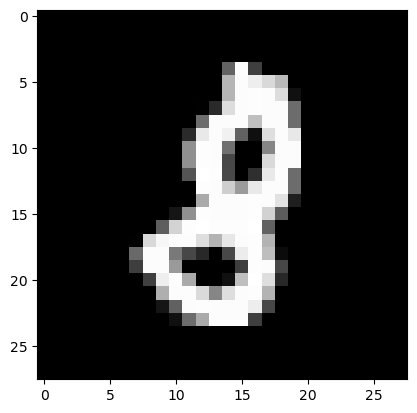

In [ ]:
test_prediction(3, W1, b1, W2, b2)